In [1]:
import os
os.environ["GOOGLE_APPLICATION_CREDENTIALS"] = "..\elt-pipeline\credentials\gcp_key.json"

In [2]:
pip install google-cloud-bigquery[pandas] pyarrow -q

Note: you may need to restart the kernel to use updated packages.


In [3]:
!pip install jupysql sqlalchemy-bigquery -q

In [4]:
%load_ext sql
%sql bigquery://bi-project-2026

c:\ProgramData\anaconda3\envs\datamining\Lib\site-packages\google\cloud\bigquery\client.py:613: UserWarning: Cannot create BigQuery Storage client, the dependency google-cloud-bigquery-storage is not installed.
  warnings.warn(


Connecting to 'bigquery://bi-project-2026'

In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go

# Overview

## KPI

In [5]:
%%sql
SELECT 
    COUNT(DISTINCT(order_id)) AS total_orders,
    SUM(delivered_qty) AS unit_sold,
    SUM(actual_revenue)/1000000000.0 AS total_revenue_billion_VND,
    SUM(expected_revenue)/1000000000.0 AS target_revenue_billion_VND,
FROM analytics.fact_order_lines


Running query in 'bigquery://bi-project-2026'

1 rows affected.

total_orders,unit_sold,total_revenue_billion_VND,target_revenue_billion_VND
31728,12969157,1243.059528,1286.761059


## Time Period

In [ ]:
%%sql
SELECT MIN(order_placement_date) AS start, MAX(actual_delivery_date) AS end
FROM analytics.fact_order_lines

Running query in 'bigquery://bi-project-2026'

1 rows affected.

start,last_end
2022-03-01,2022-09-03


# Problem: Few customers không renew contacts 
## Business Question:
- Customer nào đang có dấu hiệu at-risk?
- Delivery performance có phải nguyên nhân không?
- Nếu có, fail ở OT hay IF hay cả hai?
- Vấn đề tập trung ở product nào / thời điểm nào?

**1. At-risk Customer**
- Order frequency
- Order volumne

In [58]:
%%sql result_df<<
SELECT
    f.customer_id,
    c.customer_name,
    c.city,
    d.mmm_yy,
    MIN(d.date) AS sort_key,
    COUNT(f.order_id)   AS order_count,
    SUM(f.order_qty)    AS total_qty
FROM analytics.fact_order_lines f
JOIN analytics.dim_customers c ON f.customer_sk = c.customer_sk
JOIN analytics.dim_date d ON f.order_placement_date = d.date
GROUP BY f.customer_id, c.customer_name, c.city, d.mmm_yy
ORDER BY f.customer_id, MIN(d.date)

Running query in 'bigquery://bi-project-2026'

210 rows affected.

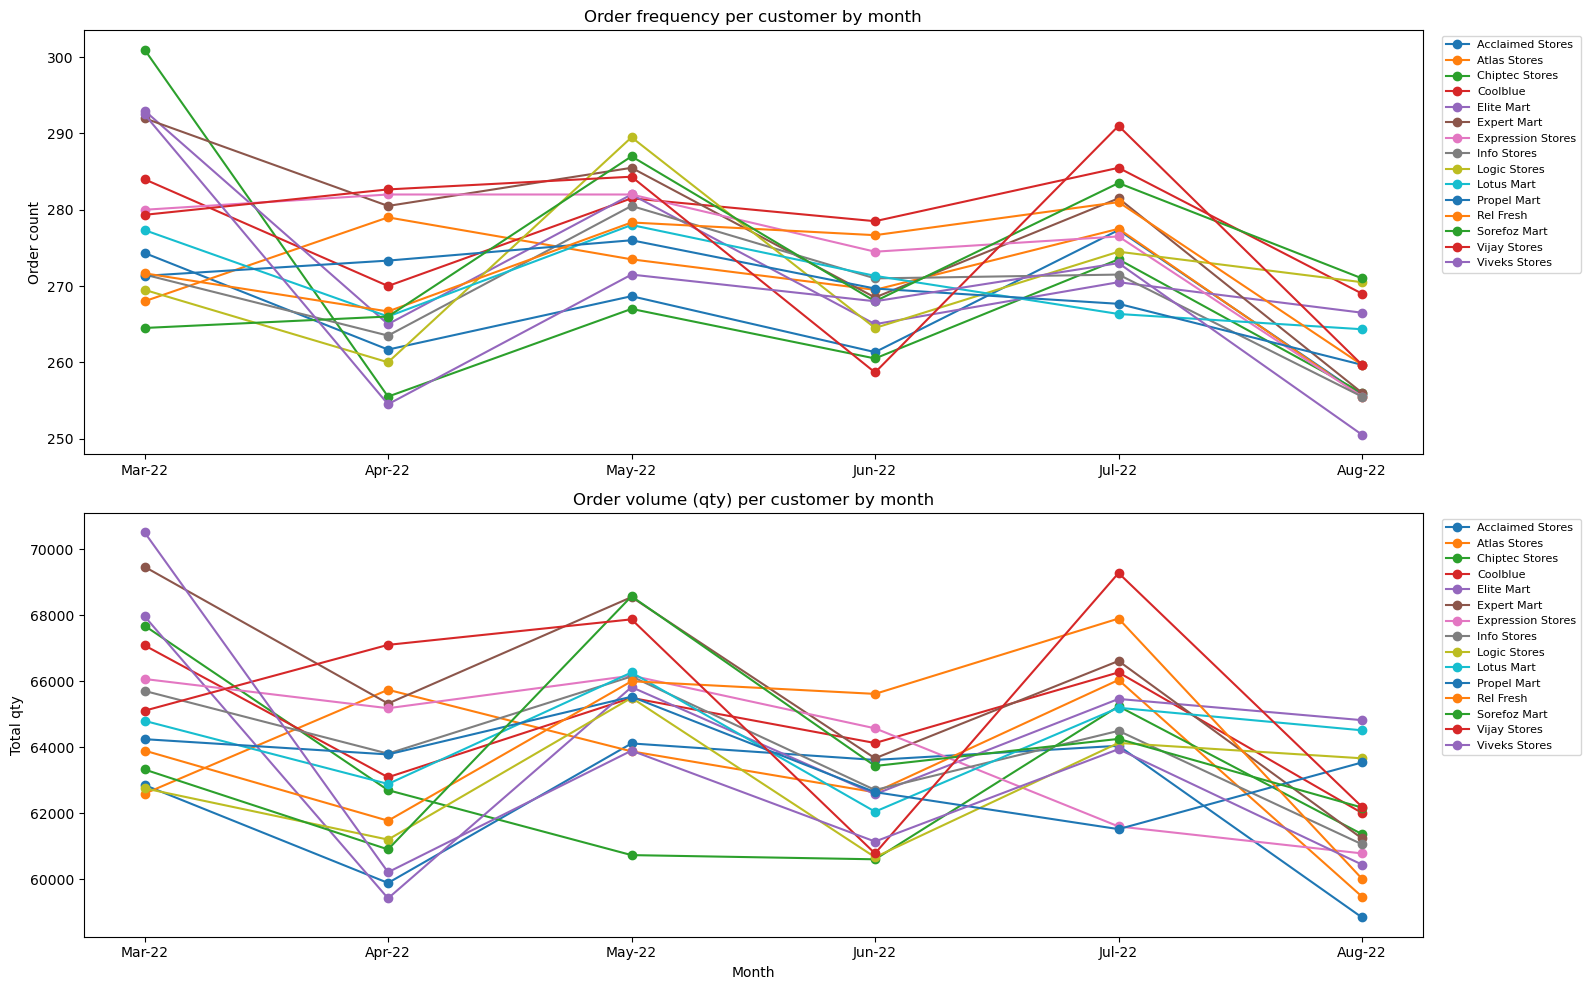

In [59]:
monthly = result_df.DataFrame()

# Sort đúng thứ tự tháng
month_order = monthly.sort_values('sort_key')['mmm_yy'].unique()

# Pivot
pivot_count = monthly.pivot_table(
    index='mmm_yy', 
    columns='customer_name', 
    values='order_count'
).loc[month_order]

pivot_qty = monthly.pivot_table(
    index='mmm_yy', 
    columns='customer_name', 
    values='total_qty'
).loc[month_order]

# Plot
fig, axes = plt.subplots(2, 1, figsize=(16, 10))

pivot_count.plot(ax=axes[0], marker='o', linewidth=1.5,
                 title='Order frequency per customer by month')
axes[0].set_xlabel('')
axes[0].set_ylabel('Order count')
axes[0].legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)

pivot_qty.plot(ax=axes[1], marker='o', linewidth=1.5,
               title='Order volume (qty) per customer by month')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Total qty')
axes[1].legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)

plt.tight_layout()
plt.show()

có seasonal fluctuation nhưng không thể hiện rõ declining trend

**2. Delivery Performance có phải nguyên nhân**
- OTIF/OT/IF overall thấp hơn target (dashboard)
- Trend theo tháng xấu đi

In [49]:
%%sql
WITH actual AS (
    SELECT
        d.mmm_yy,
        MIN(d.date) AS sort_date,
        AVG(f.on_time) * 100  AS on_time_pct,
        AVG(f.in_full) * 100  AS in_full_pct,
        AVG(f.otif) * 100     AS otif_pct
    FROM analytics.fact_orders_aggregate f
    JOIN analytics.dim_date d ON f.order_placement_date = d.date
    GROUP BY d.mmm_yy
),
target AS (
    SELECT
        AVG(ontime_target)*100 AS avg_ot_target,
        AVG(infull_target)*100 AS avg_if_target,
        AVG(otif_target)*100   AS avg_otif_target
    FROM analytics.dim_targets_orders
)
SELECT
    a.mmm_yy,
    ROUND(a.on_time_pct, 2)                        AS actual_ot,
    # ROUND(t.avg_ot_target, 2)                      AS target_ot,
    ROUND(a.on_time_pct - t.avg_ot_target, 2)      AS gap_ot,
    ROUND(a.in_full_pct, 2)                        AS actual_if,
    # ROUND(t.avg_if_target, 2)                      AS target_if,
    ROUND(a.in_full_pct - t.avg_if_target, 2)      AS gap_if,
    ROUND(a.otif_pct, 2)                           AS actual_otif,
    # ROUND(t.avg_otif_target, 2)                    AS target_otif,
    ROUND(a.otif_pct - t.avg_otif_target, 2)       AS gap_otif
FROM actual a
CROSS JOIN target t
ORDER BY a.sort_date

Running query in 'bigquery://bi-project-2026'

6 rows affected.

mmm_yy,actual_ot,gap_ot,actual_if,gap_if,actual_otif,gap_otif
Mar-22,59.58,-26.5,52.33,-24.18,28.88,-37.04
Apr-22,59.32,-26.77,52.56,-23.95,28.67,-37.24
May-22,58.5,-27.58,53.66,-22.85,29.13,-36.78
Jun-22,58.51,-27.58,52.04,-24.47,28.72,-37.2
Jul-22,59.39,-26.69,52.48,-24.03,29.35,-36.56
Aug-22,58.88,-27.2,53.61,-22.91,29.39,-36.52


In [14]:
%%sql perf_df<<
SELECT
    f.customer_id,
    c.customer_name,
    d.mmm_yy,
    MIN(d.date) AS sort_key,
    ROUND(AVG(f.on_time) * 100, 2)    AS actual_ot,
    ROUND(AVG(f.in_full) * 100, 2)    AS actual_if,
    ROUND(AVG(f.otif) * 100, 2)       AS actual_otif,
    ROUND(MAX(t.ontime_target) * 100, 2)  AS target_ot,
    ROUND(MAX(t.infull_target) * 100, 2)  AS target_if,
    ROUND(MAX(t.otif_target) * 100, 2)    AS target_otif
FROM analytics.fact_orders_aggregate f
JOIN analytics.dim_customers c ON f.customer_sk = c.customer_sk
JOIN analytics.dim_date d ON f.order_placement_date = d.date
JOIN analytics.dim_targets_orders t ON f.customer_id = t.customer_id
GROUP BY f.customer_id, c.customer_name, d.mmm_yy
ORDER BY f.customer_id, MIN(d.date)

Running query in 'bigquery://bi-project-2026'

210 rows affected.

In [15]:
perf = perf_df.DataFrame()

perf['gap_ot']   = perf['actual_ot']   - perf['target_ot']
perf['gap_if']   = perf['actual_if']   - perf['target_if']
perf['gap_otif'] = perf['actual_otif'] - perf['target_otif']

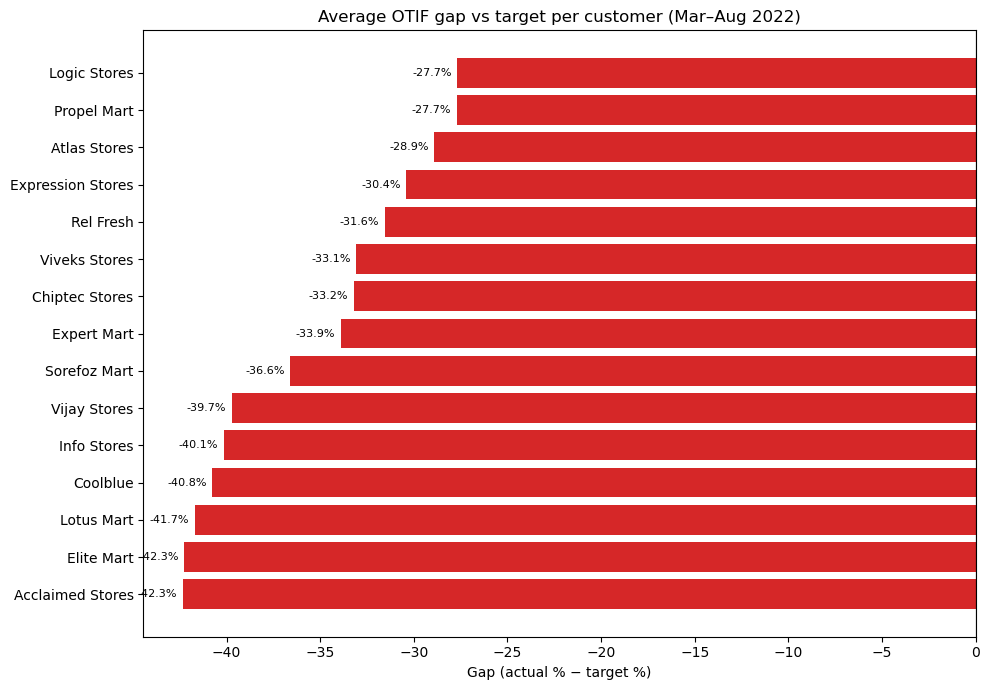

In [67]:
perf = perf_df.DataFrame()

perf['gap_otif'] = perf['actual_otif'] - perf['target_otif']

# Tính gap trung bình theo toàn bộ period per customer
avg_gap = (perf.groupby('customer_name')['gap_otif']
               .mean()
               .sort_values()
               .reset_index())

# Plot
fig, ax = plt.subplots(figsize=(10, 7))

colors = ['#d62728' if x < 0 else '#2ca02c' for x in avg_gap['gap_otif']]

ax.barh(avg_gap['customer_name'], avg_gap['gap_otif'], color=colors)
ax.axvline(x=0, color='black', linewidth=0.8)
ax.set_title('Average OTIF gap vs target per customer (Mar–Aug 2022)')
ax.set_xlabel('Gap (actual % − target %)')
ax.set_ylabel('')

# Label value trên mỗi bar
for i, (val, name) in enumerate(zip(avg_gap['gap_otif'], avg_gap['customer_name'])):
    ax.text(val + (0.3 if val >= 0 else -0.3), i, f'{val:.1f}%',
            va='center', ha='left' if val >= 0 else 'right', fontsize=8)

plt.tight_layout()
plt.show()

Delivery performance là vấn đề systemic, không phải vấn đề của một vài customers cụ thể. Lý do  customers không renew contract rất có thể là delivery performance, nhưng vấn đề không chỉ giới hạn ở "một vài customers".


In [6]:
%%sql fill_rate_df<<
SELECT
    f.customer_id,
    c.customer_name,
    c.city,
    ROUND(SUM(f.delivered_qty) / SUM(f.order_qty) * 100, 2) AS fill_rate
FROM analytics.fact_order_lines f
JOIN analytics.dim_customers c ON f.customer_sk = c.customer_sk
GROUP BY f.customer_id, c.customer_name,c.city
ORDER BY fill_rate

Running query in 'bigquery://bi-project-2026'

35 rows affected.

Có 1 vài customer có chỉ số miss target và line fill rate thấp cần chú ý: Acclaimed Stores, Coolblue, Info Stores, Elite Mart

In [7]:
%%sql delay_df<<
SELECT
    f.customer_id,
    c.customer_name,
    c.city,
    ROUND(AVG(
        DATE_DIFF(f.actual_delivery_date, f.agreed_delivery_date, DAY)
    ), 2) AS avg_delay_days
FROM analytics.fact_order_lines f
JOIN analytics.dim_customers c ON f.customer_sk = c.customer_sk
WHERE f.actual_delivery_date > f.agreed_delivery_date
GROUP BY f.customer_id, c.customer_name, c.city
ORDER BY avg_delay_days DESC

Running query in 'bigquery://bi-project-2026'

35 rows affected.

In [25]:
!pip install adjustText -q

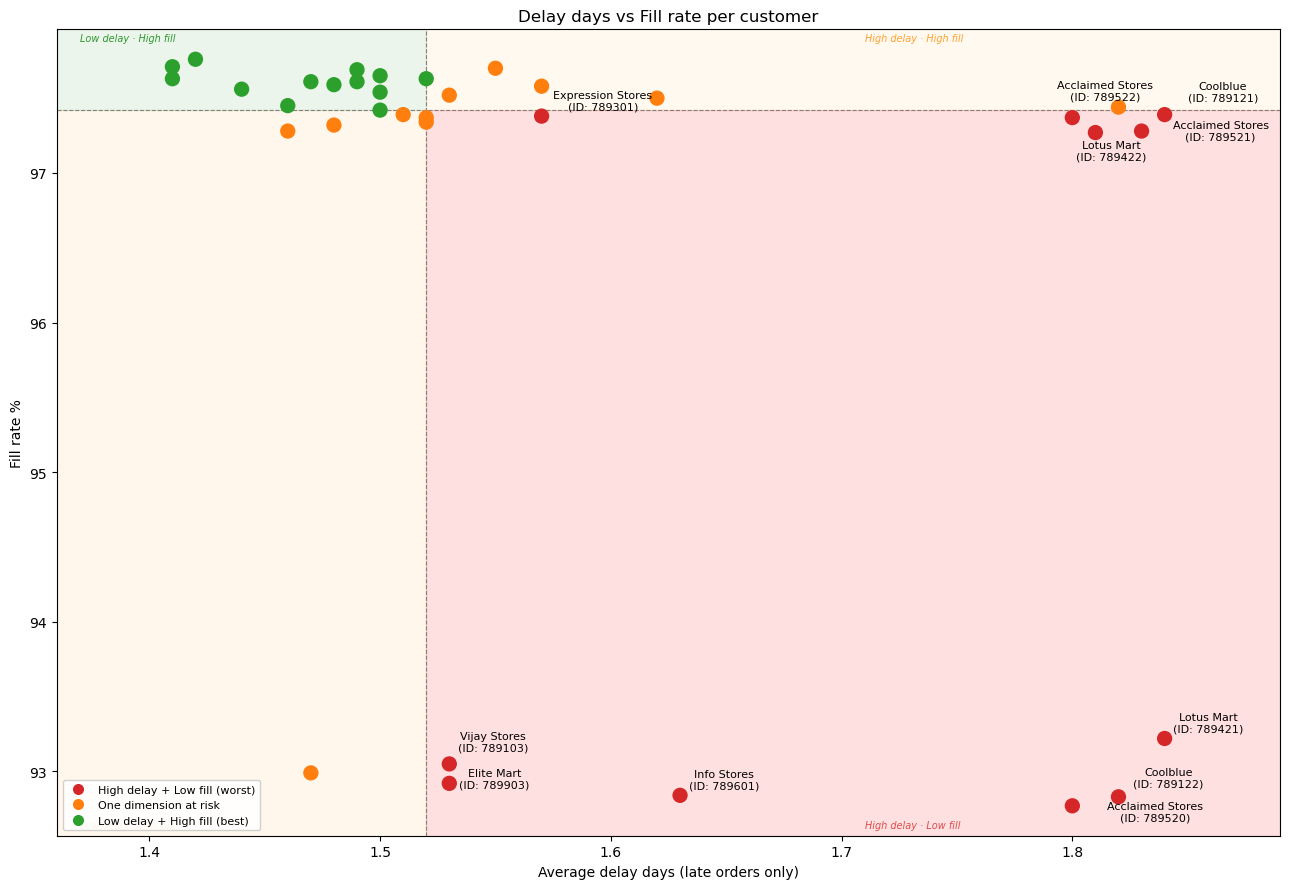

Worst customers:
        customer_name customer_id  avg_delay_days  fill_rate
7    Acclaimed Stores      789520            1.80      92.77
3            Coolblue      789122            1.82      92.83
8         Info Stores      789601            1.63      92.84
15         Elite Mart      789903            1.53      92.92
14       Vijay Stores      789103            1.53      93.05
1          Lotus Mart      789421            1.84      93.22
5          Lotus Mart      789422            1.81      97.27
2    Acclaimed Stores      789521            1.83      97.28
6    Acclaimed Stores      789522            1.80      97.37
10  Expression Stores      789301            1.57      97.38
0            Coolblue      789121            1.84      97.39


In [8]:
delay = delay_df.DataFrame()
fill  = fill_rate_df.DataFrame()

merged = delay.merge(fill, on=['customer_id', 'customer_name'])
merged['label'] = merged['customer_name'] + '\n(ID: ' + merged['customer_id'].astype(str) + ')'

med_delay = merged['avg_delay_days'].median()
med_fill  = merged['fill_rate'].median()

# Xác định worst — high delay AND low fill
worst = merged[
    (merged['avg_delay_days'] > med_delay) & 
    (merged['fill_rate'] < med_fill)
]

fig, ax = plt.subplots(figsize=(13, 9))

x_min = merged['avg_delay_days'].min() - 0.05
x_max = merged['avg_delay_days'].max() + 0.05
y_min = merged['fill_rate'].min() - 0.2
y_max = merged['fill_rate'].max() + 0.2

ax.set_xlim(x_min, x_max)
ax.set_ylim(y_min, y_max)

y_norm = (med_fill - y_min) / (y_max - y_min)

ax.axvspan(x_min, med_delay, ymin=0,      ymax=y_norm, alpha=0.08, color='orange')
ax.axvspan(med_delay, x_max, ymin=0,      ymax=y_norm, alpha=0.12, color='red')
ax.axvspan(x_min, med_delay, ymin=y_norm, ymax=1,      alpha=0.08, color='green')
ax.axvspan(med_delay, x_max, ymin=y_norm, ymax=1,      alpha=0.06, color='orange')

colors = merged.apply(lambda r:
    '#d62728' if r['avg_delay_days'] > med_delay and r['fill_rate'] < med_fill
    else '#ff7f0e' if r['avg_delay_days'] > med_delay or r['fill_rate'] < med_fill
    else '#2ca02c', axis=1)

ax.scatter(merged['avg_delay_days'], merged['fill_rate'],
           c=colors, s=100, zorder=3)

# Chỉ label worst customers
from adjustText import adjust_text
texts = [ax.text(row['avg_delay_days'], row['fill_rate'],
                 row['label'], fontsize=8)
         for _, row in worst.iterrows()]
adjust_text(texts, ax=ax)

from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#d62728',
           markersize=9, label='High delay + Low fill (worst)'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#ff7f0e',
           markersize=9, label='One dimension at risk'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#2ca02c',
           markersize=9, label='Low delay + High fill (best)'),
]
ax.legend(handles=legend_elements, loc='lower left', fontsize=8, framealpha=0.9)

ax.axvline(x=med_delay, color='gray', linewidth=0.8, linestyle='--')
ax.axhline(y=med_fill,  color='gray', linewidth=0.8, linestyle='--')

ax.text(x_min + 0.01, y_min + 0.05, 'Low delay · Low fill',
        fontsize=7, color='darkorange', alpha=0.8, style='italic')
ax.text(x_max - 0.18, y_min + 0.05, 'High delay · Low fill',
        fontsize=7, color='#d62728', alpha=0.8, style='italic')
ax.text(x_min + 0.01, y_max - 0.08, 'Low delay · High fill',
        fontsize=7, color='green', alpha=0.8, style='italic')
ax.text(x_max - 0.18, y_max - 0.08, 'High delay · High fill',
        fontsize=7, color='darkorange', alpha=0.8, style='italic')

ax.set_xlabel('Average delay days (late orders only)')
ax.set_ylabel('Fill rate %')
ax.set_title('Delay days vs Fill rate per customer')
plt.tight_layout()
plt.show()

print("Worst customers:")
print(worst[['customer_name', 'customer_id', 'avg_delay_days', 'fill_rate']]
      .sort_values('fill_rate'))

In [ ]:
delay = delay_df.DataFrame()
fill  = fill_rate_df.DataFrame()

merged = delay.merge(fill, on=['customer_id', 'customer_name'])
merged['label'] = merged['customer_name'] + ' (ID: ' + merged['customer_id'].astype(str) + ')'

med_delay = merged['avg_delay_days'].median()
med_fill  = merged['fill_rate'].median()

merged['quadrant'] = merged.apply(lambda r:
    'High delay + Low fill (worst)' if r['avg_delay_days'] > med_delay and r['fill_rate'] < med_fill
    else 'One dimension at risk' if r['avg_delay_days'] > med_delay or r['fill_rate'] < med_fill
    else 'Low delay + High fill (best)', axis=1)

color_map = {
    'High delay + Low fill (worst)': '#d62728',
    'One dimension at risk':         '#ff7f0e',
    'Low delay + High fill (best)':  '#2ca02c'
}

fig = go.Figure()

for quadrant, group in merged.groupby('quadrant'):
    fig.add_trace(go.Scatter(
        x=group['avg_delay_days'],
        y=group['fill_rate'],
        mode='markers',
        name=quadrant,
        marker=dict(color=color_map[quadrant], size=12),
        hovertemplate=(
            '<b>%{customdata[0]}</b><br>'
            'Avg delay: %{x:.2f} days<br>'
            'Fill rate: %{y:.2f}%<br>'
            '<extra></extra>'
        ),
        customdata=group[['label']].values
    ))

# Quadrant lines
fig.add_hline(y=med_fill,  line_dash='dash', line_color='gray', line_width=1)
fig.add_vline(x=med_delay, line_dash='dash', line_color='gray', line_width=1)

# Quadrant annotations
fig.add_annotation(x=med_delay - 0.02, y=merged['fill_rate'].max() - 0.02,
                   text='Low delay · High fill', showarrow=False,
                   font=dict(size=10, color='green'), xanchor='right')
fig.add_annotation(x=med_delay + 0.02, y=merged['fill_rate'].max() - 0.02,
                   text='High delay · High fill', showarrow=False,
                   font=dict(size=10, color='darkorange'), xanchor='left')
fig.add_annotation(x=med_delay - 0.02, y=merged['fill_rate'].min() + 0.02,
                   text='Low delay · Low fill', showarrow=False,
                   font=dict(size=10, color='darkorange'), xanchor='right')
fig.add_annotation(x=med_delay + 0.02, y=merged['fill_rate'].min() + 0.02,
                   text='High delay · Low fill ⚠', showarrow=False,
                   font=dict(size=10, color='#d62728'), xanchor='left')

fig.update_layout(
    title='Delay days vs Fill rate per customer',
    xaxis_title='Average delay days (late orders only)',
    yaxis_title='Fill rate %',
    legend_title='Quadrant',
    plot_bgcolor='white',
    paper_bgcolor='white',
    hovermode='closest'
)

fig.update_xaxes(showgrid=False)
fig.update_yaxes(showgrid=False)

fig.show()



In [9]:
%%sql late_pct_df<<
SELECT
    f.customer_id,
    c.customer_name,
    ROUND(
        COUNTIF(f.actual_delivery_date > f.agreed_delivery_date) 
        / COUNT(f.order_id) * 100, 2
    ) AS late_pct,
    COUNT(f.order_id) AS total_orders,
    COUNTIF(f.actual_delivery_date > f.agreed_delivery_date) AS late_orders
FROM analytics.fact_order_lines f
JOIN analytics.dim_customers c ON f.customer_sk = c.customer_sk
GROUP BY f.customer_id, c.customer_name
ORDER BY late_pct DESC

Running query in 'bigquery://bi-project-2026'

35 rows affected.

In [10]:
late = late_pct_df.DataFrame()
worst_late = late[late['customer_id'].isin(worst['customer_id'])]
worst_late[['customer_id', 'customer_name', 'late_pct', 'total_orders', 'late_orders']]
    

,customer_id,customer_name,late_pct,total_orders,late_orders
1,789422,Lotus Mart,74.24,1603,1190
2,789522,Acclaimed Stores,74.14,1597,1184
3,789421,Lotus Mart,73.72,1602,1181
4,789122,Coolblue,73.37,1675,1229
5,789521,Acclaimed Stores,73.32,1634,1198
6,789121,Coolblue,72.98,1662,1213
7,789520,Acclaimed Stores,71.84,1566,1125
10,789301,Expression Stores,17.14,1680,288
18,789601,Info Stores,16.30,1620,264
23,789903,Elite Mart,15.36,1641,252


Contribution (revenue + purchases) của 11 khách hàng này

C:\Users\ASUS\AppData\Local\Temp\ipykernel_2952\1467859015.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  worst_late['label'] = worst_late['customer_name'] + '\n(ID: ' + worst_late['customer_id'].astype(str) + ')'


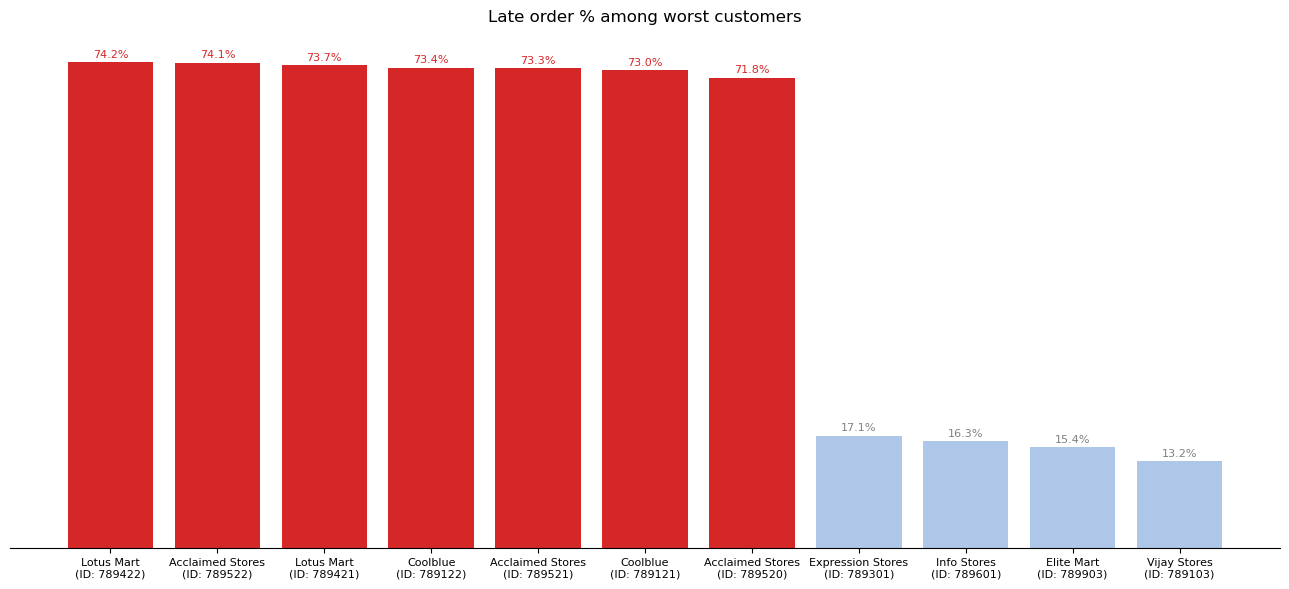

In [11]:
worst_late['label'] = worst_late['customer_name'] + '\n(ID: ' + worst_late['customer_id'].astype(str) + ')'
df_sorted = worst_late.sort_values('late_pct', ascending=False)

threshold = 50  # highlight bars cao hơn 50%
colors = ['#d62728' if v > threshold else '#aec7e8' for v in df_sorted['late_pct']]

fig, ax = plt.subplots(figsize=(13, 6))

bars = ax.bar(df_sorted['label'], df_sorted['late_pct'], color=colors)

# Data labels trên mỗi bar
for bar, val in zip(bars, df_sorted['late_pct']):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.5,
            f'{val:.1f}%',
            ha='center', va='bottom', fontsize=8,
            color='#d62728' if val > threshold else 'gray')

# Bỏ y axis
ax.yaxis.set_visible(False)
ax.spines[['left', 'top', 'right']].set_visible(False)

ax.set_xlabel('')
ax.set_title('Late order % among worst customers', pad=12)
plt.xticks(fontsize=8)
plt.tight_layout()
plt.show()

- Việc delay trầm trọng ở top 7 khách hàng trên có risk tới overall revenue?
- 7 khách hàng này thường bị delay order ở các mặt hàng gì?

In [16]:
worst_ids = worst_late['customer_id'].tolist()

perf_worst = perf[perf['customer_id'].isin(worst_ids)].copy()
perf_worst = perf_worst.sort_values('sort_key')

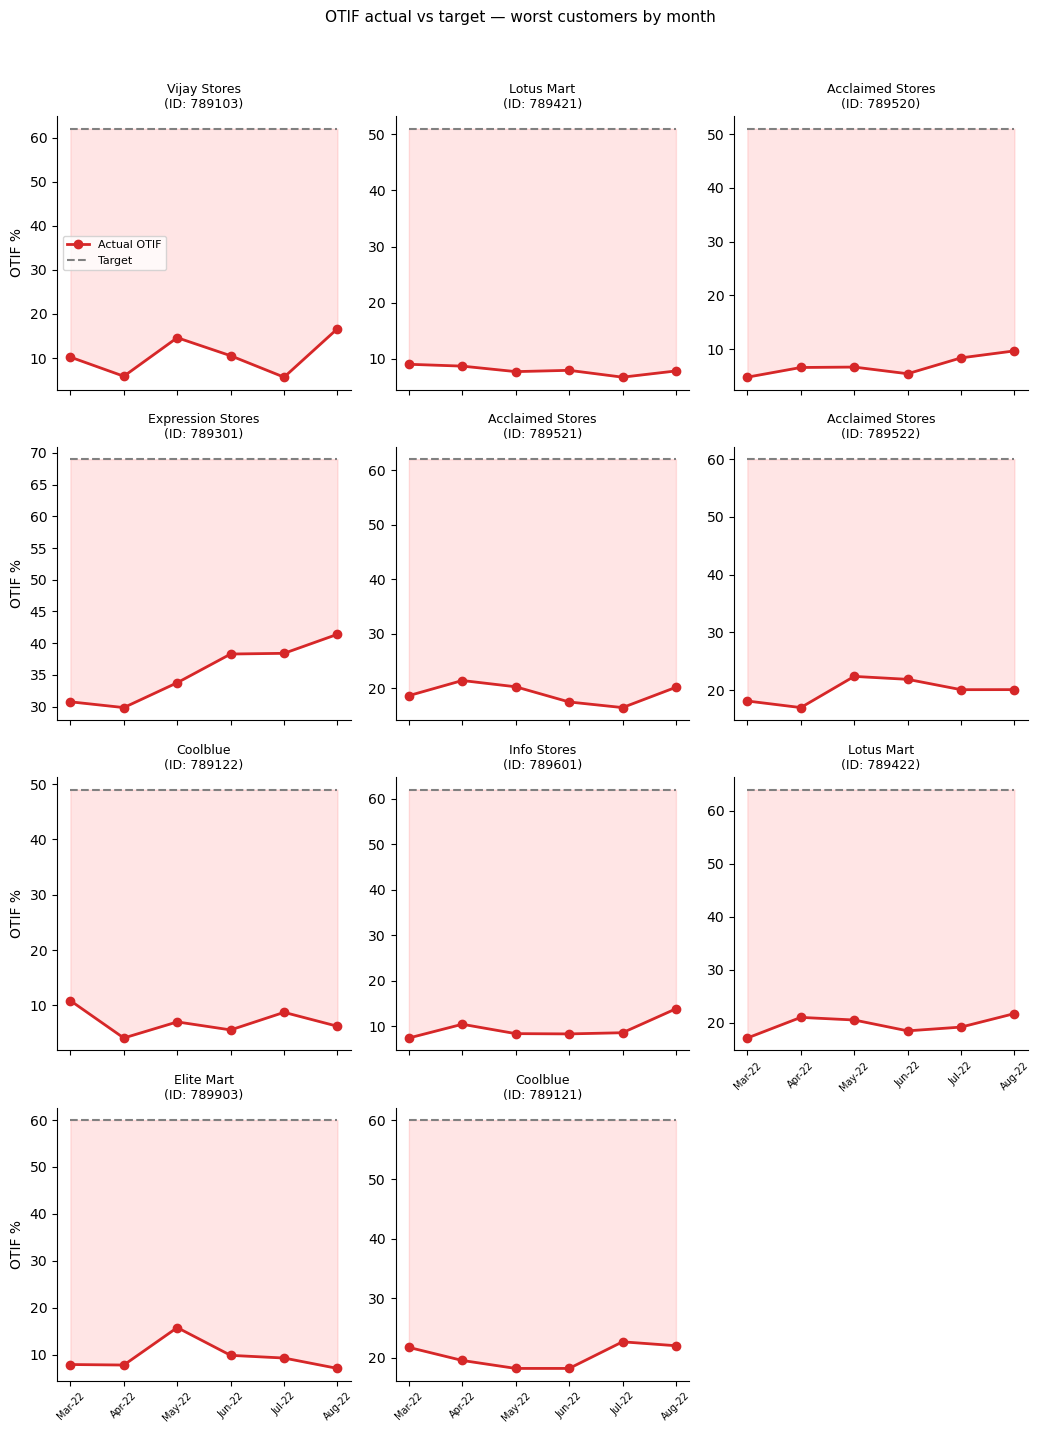

In [25]:
month_order = perf_worst.sort_values('sort_key')['mmm_yy'].unique()

perf_worst['label'] = perf_worst['customer_name'] + '\n(ID: ' + perf_worst['customer_id'].astype(str) + ')'

g = sns.FacetGrid(perf_worst, col='label', col_wrap=3, height=3.5, sharey=False)
g.set_titles(col_template='{col_name}', size=9)
def plot_otif(data, **kwargs):
    ax = plt.gca()
    ax.plot(data['mmm_yy'], data['actual_otif'],
            marker='o', color='#d62728', linewidth=2, label='Actual OTIF')
    ax.plot(data['mmm_yy'], data['target_otif'],
            marker='', color='gray', linewidth=1.5,
            linestyle='--', label='Target')
    ax.fill_between(data['mmm_yy'], data['actual_otif'], data['target_otif'],
                    alpha=0.1, color='red')
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=45, labelsize=7)

g.map_dataframe(plot_otif)
g.set_titles(col_template='{col_name}', size=9)
g.set_ylabels('OTIF %')

# Shared legend
g.axes[0].legend(fontsize=8, loc='center left')

g.figure.suptitle('OTIF actual vs target — worst customers by month',
                   y=1.02, fontsize=11)
plt.tight_layout()
plt.show()

In [28]:
%%sql product_perf_df<<
SELECT
    p.category,
    p.product_name,
    p.product_id,
    COUNT(f.order_id) AS total_orders,
    ROUND(AVG(f.delivered_qty / f.order_qty) * 100, 2) AS fill_rate,
    ROUND(COUNTIF(f.actual_delivery_date > f.agreed_delivery_date) 
          / COUNT(f.order_id) * 100, 2) AS late_pct,
    ROUND(AVG(DATE_DIFF(f.actual_delivery_date, 
              f.agreed_delivery_date, DAY)), 2) AS avg_delay_days
FROM analytics.fact_order_lines f
JOIN analytics.dim_products p ON f.product_sk = p.product_sk
GROUP BY p.category, p.product_name, p.product_id
ORDER BY fill_rate

Running query in 'bigquery://bi-project-2026'

18 rows affected.

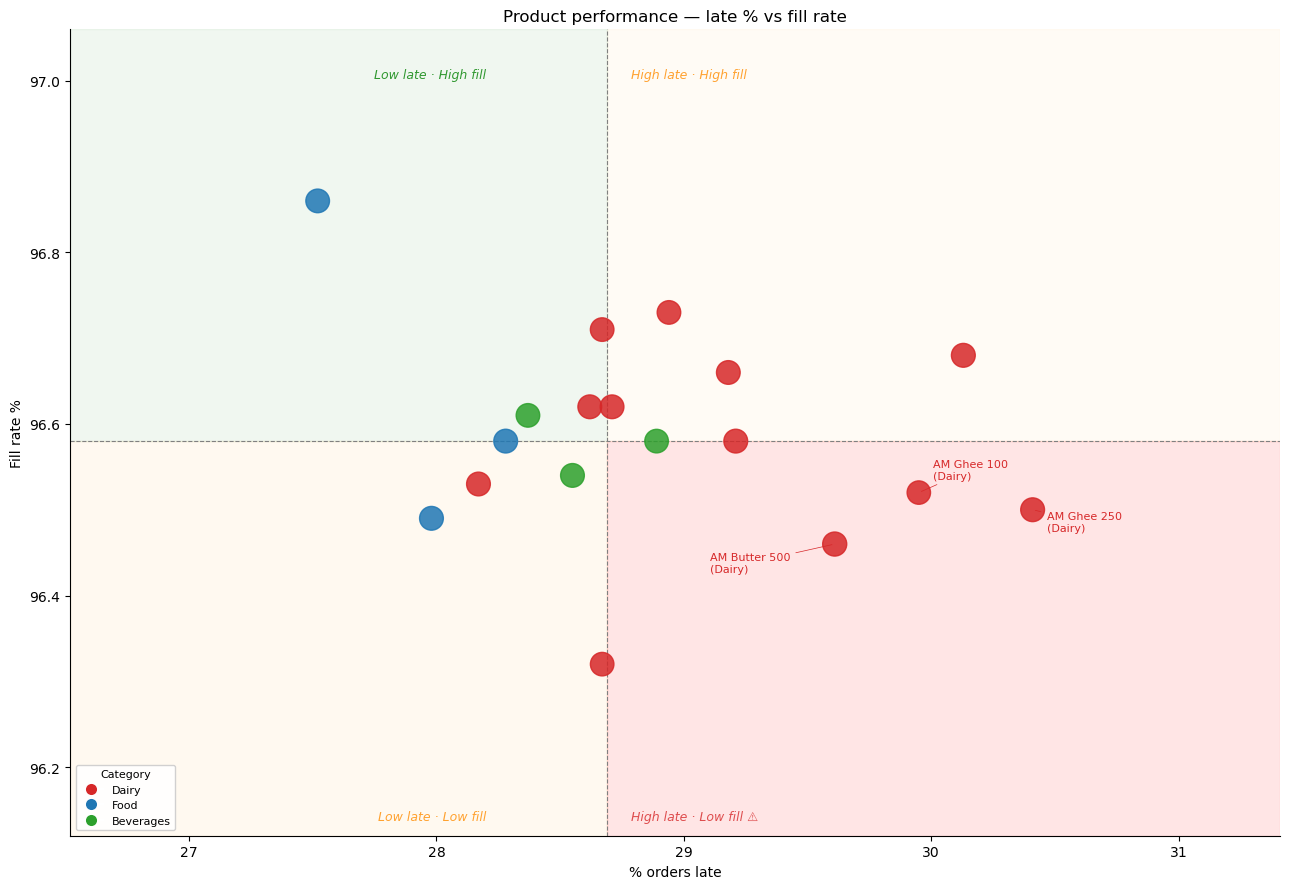

In [40]:
prod = product_perf_df.DataFrame()

med_fill = prod['fill_rate'].median()
med_late = prod['late_pct'].median()

prod['label'] = prod['product_name'] + '\n(' + prod['category'] + ')'

worst_prod = prod[
    (prod['late_pct'] > med_late) &
    (prod['fill_rate'] < med_fill)
]

categories = prod['category'].unique()
palette = dict(zip(categories,
                   ['#d62728','#1f77b4','#2ca02c','#ff7f0e','#9467bd']))

colors = prod['category'].map(palette)
sizes = (prod['total_orders'] / prod['total_orders'].max() * 300).clip(lower=40)

fig, ax = plt.subplots(figsize=(13, 9))

x_min = prod['late_pct'].min() - 1
x_max = prod['late_pct'].max() + 1
y_min = prod['fill_rate'].min() - 0.2
y_max = prod['fill_rate'].max() + 0.2

ax.set_xlim(x_min, x_max)
ax.set_ylim(y_min, y_max)

y_norm = (med_fill - y_min) / (y_max - y_min)

ax.axvspan(x_min, med_late, ymin=0,      ymax=y_norm, alpha=0.06, color='orange')
ax.axvspan(med_late, x_max, ymin=0,      ymax=y_norm, alpha=0.10, color='red')
ax.axvspan(x_min, med_late, ymin=y_norm, ymax=1,      alpha=0.06, color='green')
ax.axvspan(med_late, x_max, ymin=y_norm, ymax=1,      alpha=0.04, color='orange')

ax.scatter(prod['late_pct'], prod['fill_rate'],
           c=colors, s=sizes, zorder=3, alpha=0.85)

# Manual offset để tránh overlap
offsets = {
    'AM Butter 500': (-90, -20),
    'AM Ghee 250':   (10,  -15),
    'AM Ghee 100':   (10,   10),
}
for _, row in worst_prod.iterrows():
    dx, dy = offsets.get(row['product_name'], (8, 8))
    ax.annotate(row['label'],
                xy=(row['late_pct'], row['fill_rate']),
                xytext=(dx, dy), textcoords='offset points',
                fontsize=8, color='#d62728',
                arrowprops=dict(arrowstyle='-', color='#d62728', lw=0.5))

ax.axvline(x=med_late, color='gray', linewidth=0.8, linestyle='--')
ax.axhline(y=med_fill, color='gray', linewidth=0.8, linestyle='--')

x_range = x_max - x_min
y_range = y_max - y_min

ax.text(med_late - x_range * 0.10, y_max - y_range * 0.06,
        'Low late · High fill',
        fontsize=9, color='green', alpha=0.8, style='italic',
        ha='right')
ax.text(med_late + x_range * 0.02, y_max - y_range * 0.06,
        'High late · High fill',
        fontsize=9, color='darkorange', alpha=0.8, style='italic',
        ha='left')
ax.text(med_late - x_range * 0.10, y_min + y_range * 0.02,
        'Low late · Low fill',
        fontsize=9, color='darkorange', alpha=0.8, style='italic',
        ha='right')
ax.text(med_late + x_range * 0.02, y_min + y_range * 0.02,
        'High late · Low fill ⚠',
        fontsize=9, color='#d62728', alpha=0.8, style='italic',
        ha='left')

from matplotlib.lines import Line2D
color_legend = [
    Line2D([0], [0], marker='o', color='w',
           markerfacecolor=palette[cat], markersize=9, label=cat)
    for cat in categories
]
ax.legend(handles=color_legend,
          loc='lower left', fontsize=8, framealpha=0.9,
          title='Category', title_fontsize=8)

ax.set_xlabel('% orders late')
ax.set_ylabel('Fill rate %')
ax.set_title('Product performance — late % vs fill rate')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

In [ ]:
prod['label'] = prod['product_name'] + ' (' + prod['category'] + ')'

fig = px.scatter(
    prod,
    x='late_pct',
    y='fill_rate',
    color='category',
    size='total_orders',
    hover_name='label',
    hover_data={
        'late_pct': ':.2f',
        'fill_rate': ':.2f',
        'total_orders': True,
        'category': False,
        'label': False
    },
    color_discrete_map={
        'Dairy':     '#d62728',
        'Food':      '#1f77b4',
        'Beverages': '#2ca02c'
    },
    title='Product performance — late % vs fill rate'
)

# Quadrant lines
fig.add_hline(y=med_fill, line_dash='dash', line_color='gray', line_width=1)
fig.add_vline(x=med_late, line_dash='dash', line_color='gray', line_width=1)

# Quadrant annotations
fig.add_annotation(x=med_late - 0.3, y=prod['fill_rate'].max() - 0.02,
                   text='Low late · High fill', showarrow=False,
                   font=dict(size=10, color='green'), xanchor='right')
fig.add_annotation(x=med_late + 0.1, y=prod['fill_rate'].max() - 0.02,
                   text='High late · High fill', showarrow=False,
                   font=dict(size=10, color='darkorange'), xanchor='left')
fig.add_annotation(x=med_late - 0.3, y=prod['fill_rate'].min() + 0.02,
                   text='Low late · Low fill', showarrow=False,
                   font=dict(size=10, color='darkorange'), xanchor='right')
fig.add_annotation(x=med_late + 0.1, y=prod['fill_rate'].min() + 0.02,
                   text='High late · Low fill ⚠', showarrow=False,
                   font=dict(size=10, color='#d62728'), xanchor='left')

fig.update_layout(
    xaxis_title='% orders late',
    yaxis_title='Fill rate %',
    legend_title='Category',
    plot_bgcolor='white',
    paper_bgcolor='white',
    hovermode='closest'
)

fig.update_xaxes(showgrid=False)
fig.update_yaxes(showgrid=False)

fig.show()